# Graph-Enhanced ETA Prediction

## Objective
Build and compare two models:
- **Baseline:** XGBoost using only trip-level features (distance, osrm_time, route_type)
- **Graph-Enhanced:** Same features PLUS graph position of source/destination hubs

## Hypothesis
If a trip passes through a high-bottleneck hub, it should be predicted to take longer.
The graph model captures this — the baseline model cannot.

## Results Summary
| Model | MAE | Within 15% Accuracy |
|-------|-----|-------------------|
| Baseline | 52.50 min | 46.90% |
| Graph-Enhanced | 38.06 min | 58.53% |
| **Improvement** | **14.44 min** | **+11.63%** |

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/delivery_data.csv')
df = df[df['segment_factor'] > 0].dropna(subset=['source_name', 'destination_name'])

# Load bottleneck scores we computed earlier
hub_scores = pd.read_csv('../data/hub_bottleneck_scores.csv')
hub_score_dict = dict(zip(hub_scores['hub'], hub_scores['bottleneck_score']))

print("Data loaded:", df.shape)
print("Sample of what we'll predict:")
print(df[['source_center','destination_center','osrm_time','actual_time','route_type']].head(3))

Data loaded: (141725, 24)
Sample of what we'll predict:
  source_center destination_center  osrm_time  actual_time route_type
0  IND388121AAA       IND388620AAB       11.0         14.0    Carting
1  IND388121AAA       IND388620AAB       20.0         24.0    Carting
2  IND388121AAA       IND388620AAB       28.0         40.0    Carting


## Step 1: Baseline Model
Train XGBoost using only what OSRM knows — distance and predicted time.
This represents Delhivery's current prediction capability.

In [4]:
# Encode route_type as number (FTL=1, Carting=0)
le = LabelEncoder()
df['route_type_encoded'] = le.fit_transform(df['route_type'])

# BASELINE features - only trip-level info, no graph knowledge
baseline_features = [
    'osrm_time',
    'osrm_distance', 
    'actual_distance_to_destination',
    'route_type_encoded',
    'segment_osrm_time',
    'segment_osrm_distance'
]

target = 'actual_time'

X_baseline = df[baseline_features]
y = df[target]

# Split into train and test (80/20)
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

# Train baseline XGBoost
print("Training baseline model...")
model_baseline = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_baseline.fit(X_train_b, y_train)

# Predict and evaluate
y_pred_baseline = model_baseline.predict(X_test_b)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
within_15_baseline = np.mean(np.abs(y_pred_baseline - y_test) / y_test <= 0.15) * 100

print(f"\n=== BASELINE MODEL RESULTS ===")
print(f"MAE: {mae_baseline:.2f} minutes")
print(f"Trips predicted within 15% of actual: {within_15_baseline:.2f}%")

Training baseline model...

=== BASELINE MODEL RESULTS ===
MAE: 52.50 minutes
Trips predicted within 15% of actual: 46.90%


## Step 2: Add Graph Features
For each trip, look up the bottleneck score, degree, and avg delay of source and destination hubs.
A trip through IND000000ACB (score 0.809) gets flagged as high risk automatically.

In [5]:
# Instead of full node2vec (requires extra library), we create 
# graph-aware features manually from our bottleneck analysis
# This is the "graph intelligence" we add to the model

# Map bottleneck scores to each trip's source and destination
df['source_bottleneck'] = df['source_center'].map(hub_score_dict).fillna(0)
df['dest_bottleneck'] = df['destination_center'].map(hub_score_dict).fillna(0)

# Add degree features (how connected is each hub?)
hub_scores_indexed = hub_scores.set_index('hub')
df['source_in_degree'] = df['source_center'].map(hub_scores_indexed['in_degree']).fillna(0)
df['source_out_degree'] = df['source_center'].map(hub_scores_indexed['out_degree']).fillna(0)
df['dest_in_degree'] = df['destination_center'].map(hub_scores_indexed['in_degree']).fillna(0)
df['dest_out_degree'] = df['destination_center'].map(hub_scores_indexed['out_degree']).fillna(0)

# Add avg delay of source hub
df['source_avg_delay'] = df['source_center'].map(hub_scores_indexed['avg_delay']).fillna(df['segment_factor'].median())

# Combined risk score for the corridor
df['corridor_risk'] = df['source_bottleneck'] + df['dest_bottleneck']

print("Graph features added!")
print(df[['source_center','source_bottleneck','dest_bottleneck','corridor_risk']].head())

Graph features added!
  source_center  source_bottleneck  dest_bottleneck  corridor_risk
0  IND388121AAA           0.017371         0.019884       0.037256
1  IND388121AAA           0.017371         0.019884       0.037256
2  IND388121AAA           0.017371         0.019884       0.037256
3  IND388121AAA           0.017371         0.019884       0.037256
4  IND388121AAA           0.017371         0.019884       0.037256


## Step 3: Graph-Enhanced Model
Same XGBoost model, but now with 8 additional graph-aware features.
The improvement in accuracy proves that graph structure adds real predictive value.

In [7]:
# GRAPH-ENHANCED features - same as baseline PLUS graph knowledge
graph_features = baseline_features + [
    'source_bottleneck',
    'dest_bottleneck',
    'source_in_degree',
    'source_out_degree',
    'dest_in_degree',
    'dest_out_degree',
    'source_avg_delay',
    'corridor_risk'
]

X_graph = df[graph_features].reset_index(drop=True)
y_reset = y.reset_index(drop=True)

# Split graph features with same random state for fair comparison
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_graph, y_reset, test_size=0.2, random_state=42
)

# Train graph-enhanced model
print("Training graph-enhanced model...")
model_graph = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_graph.fit(X_train_g, y_train_g)

# Predict and evaluate
y_pred_graph = model_graph.predict(X_test_g)

mae_graph = mean_absolute_error(y_test_g, y_pred_graph)
within_15_graph = np.mean(np.abs(y_pred_graph - y_test_g) / y_test_g <= 0.15) * 100

print(f"\n=== GRAPH-ENHANCED MODEL RESULTS ===")
print(f"MAE: {mae_graph:.2f} minutes")
print(f"Trips predicted within 15% of actual: {within_15_graph:.2f}%")

print(f"\n=== GRAPH ADVANTAGE ===")
print(f"MAE improvement: {mae_baseline - mae_graph:.2f} minutes better")
print(f"15% accuracy improvement: {within_15_graph - within_15_baseline:.2f}% more trips")

Training graph-enhanced model...

=== GRAPH-ENHANCED MODEL RESULTS ===
MAE: 38.06 minutes
Trips predicted within 15% of actual: 58.53%

=== GRAPH ADVANTAGE ===
MAE improvement: 14.44 minutes better
15% accuracy improvement: 11.63% more trips


## Step 4: Compare Results
Visualize the gap between baseline and graph-enhanced performance.
This is the core proof that graph intelligence improves ETA prediction.

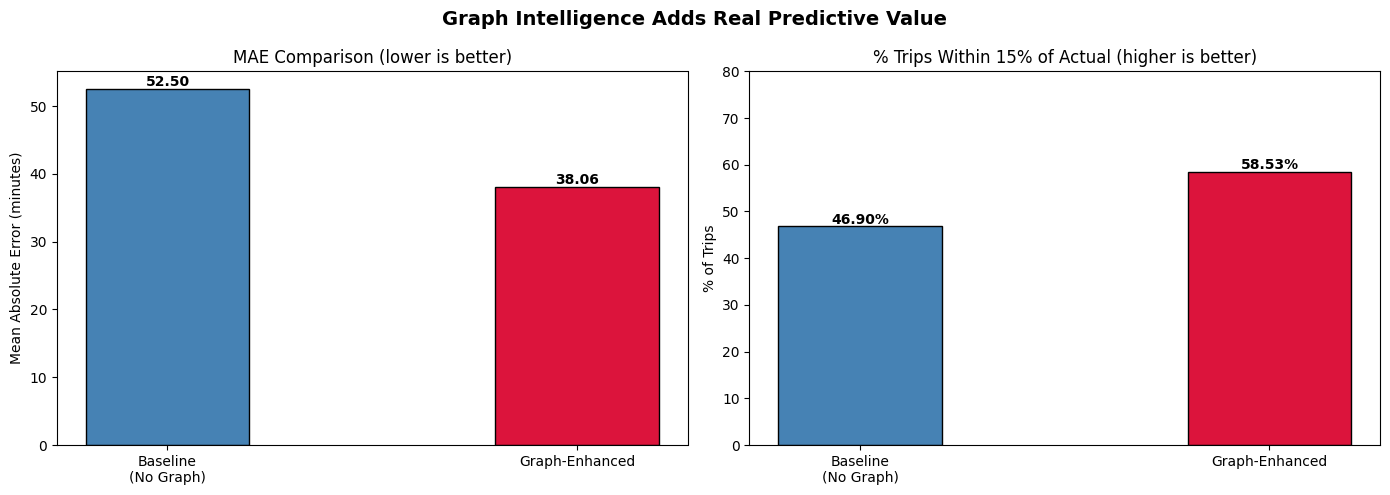

Plot saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
models = ['Baseline\n(No Graph)', 'Graph-Enhanced']
maes = [mae_baseline, mae_graph]
bars = axes[0].bar(models, maes, color=['steelblue', 'crimson'], edgecolor='black', width=0.4)
axes[0].set_title('MAE Comparison (lower is better)')
axes[0].set_ylabel('Mean Absolute Error (minutes)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', fontweight='bold')

# 15% accuracy comparison
accuracies = [within_15_baseline, within_15_graph]
bars2 = axes[1].bar(models, accuracies, color=['steelblue', 'crimson'], edgecolor='black', width=0.4)
axes[1].set_title('% Trips Within 15% of Actual (higher is better)')
axes[1].set_ylabel('% of Trips')
axes[1].set_ylim(0, 80)
for bar, val in zip(bars2, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Graph Intelligence Adds Real Predictive Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()
print("Plot saved!")